# Temperature model - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-04

# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import re
import math

# Import Database

In [2]:
database = 'Processability and Product Properties Data Library of mcl-PHAs_V03.xlsx'

# Create DataFrames for each type of properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(database, sheet_name='Physchem_properties')

# Thermal properties DataFrame
df_therm = pd.read_excel(database, sheet_name='Thermal_properties')

# Process Physicochemical properties DataFrame

In [4]:
# Check for columns names and null values
df_physicochem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Study_id                                431 non-null    float64
 1   Instance                                431 non-null    float64
 2   scl PHA ratio (mol%)                    431 non-null    float64
 3   3HB ratio (mol%)                        431 non-null    float64
 4   3HV ratio (mol%)                        431 non-null    float64
 5   mcl PHA ratio (mol%)                    431 non-null    float64
 6   3HHx ratio (mol%)                       426 non-null    float64
 7   3HHp ratio (mol%)                       431 non-null    float64
 8   3HO ratio (mol%)                        431 non-null    float64
 9   3HN ratio (mol%)                        431 non-null    float64
 10  3HD ratio (mol%)                        426 non-null    float6

In [5]:
df_therm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Study_id                  431 non-null    float64
 1   Instance                  431 non-null    float64
 2   Tg1                       345 non-null    float64
 3   Tg2                       3 non-null      float64
 4   Tc1                       58 non-null     float64
 5   Tc2                       20 non-null     float64
 6   Tmc                       26 non-null     float64
 7   Tm1                       330 non-null    float64
 8   Tm2                       69 non-null     float64
 9   Td5                       105 non-null    float64
 10  Tdeg                      10 non-null     float64
 11  Temperature_units         404 non-null    object 
 12  DΗm1                      240 non-null    float64
 13  DΗm2                      6 non-null      float64
 14  DHc1      

## Merge thermal properties

In [6]:
def add_max_mean_columns(df, col1, col2, prefix):
    """
    Creates {prefix}_mean and {prefix}_max from col1/col2:
    - Both exist: mean / max of the two
    - Only one exists: that value (for both new columns)
    - Neither exists: NaN
    """
    df[f"{prefix}_mean"] = df[[col1, col2]].mean(axis=1, skipna=True)
    df[f"{prefix}_max"] = df[[col1, col2]].max(axis=1, skipna=True)
    return df


# ---- Usage ----
df_therm = add_max_mean_columns(df_therm, "Tm1", "Tm2", "tm")
df_therm = add_max_mean_columns(df_therm, "Tc1", "Tc2", "tc")

# Quick check
print(df_therm[["Tm1", "Tm2", "tm_mean", "tm_max", "Tc1", "Tc2", "tc_mean", "tc_max"]].head(10))
print("\nNon-null counts:")
print(df_therm[["tm_mean", "tm_max", "tc_mean", "tc_max"]].notna().sum())

     Tm1    Tm2  tm_mean  tm_max   Tc1  Tc2  tc_mean  tc_max
0  176.0    NaN    176.0   176.0   NaN  NaN      NaN     NaN
1  155.0  167.0    161.0   167.0  59.0  NaN     59.0    59.0
2  141.0  157.0    149.0   157.0  58.0  NaN     58.0    58.0
3  161.0    NaN    161.0   161.0   NaN  NaN      NaN     NaN
4   52.0    NaN     52.0    52.0   NaN  NaN      NaN     NaN
5  163.7    NaN    163.7   163.7  63.4  NaN     63.4    63.4
6  163.8    NaN    163.8   163.8  56.5  NaN     56.5    56.5
7  163.9    NaN    163.9   163.9  64.3  NaN     64.3    64.3
8  161.0    NaN    161.0   161.0   NaN  NaN      NaN     NaN
9  157.0    NaN    157.0   157.0   NaN  NaN      NaN     NaN

Non-null counts:
tm_mean    334
tm_max     334
tc_mean     62
tc_max      62
dtype: int64


In [8]:
# Process Mw, Mn and PDI columns
# PDI = Mw/Mn

mask_Mw = (
    df_physicochem['Mw'].isna() &
    df_physicochem['Mn'].notna() &
    df_physicochem['PDI'].notna()
)

mask_Mn = (
    df_physicochem['Mn'].isna() &
    df_physicochem['Mw'].notna() &
    df_physicochem['PDI'].notna()
)

mask_PDI = (
    df_physicochem['PDI'].isna() &
    df_physicochem['Mw'].notna() &
    df_physicochem['Mn'].notna()
)


df_physicochem.loc[mask_Mw, 'Mw'] = (
    df_physicochem.loc[mask_Mw, 'PDI'] * df_physicochem.loc[mask_Mw, 'Mn']
)

df_physicochem.loc[mask_Mn, 'Mn'] = (
    df_physicochem.loc[mask_Mn, 'Mw'] / df_physicochem.loc[mask_Mn, 'PDI']
)

df_physicochem.loc[mask_PDI, 'PDI'] = (
    df_physicochem.loc[mask_PDI, 'Mw'] / df_physicochem.loc[mask_PDI, 'Mn']
)

In [9]:
# Categorical columns to fill with 'not_applicable'
categorical_cols = ['Additive1_type', 'Additive2_type']

# Numerical columns to fill with 0
numeric_cols = ['Additive1_percentage (wt%)', 'Additive2_percentage (wt%)']

# Fill categorical columns
for col in categorical_cols:
    df_physicochem[col] = df_physicochem[col].fillna('no_additive').astype(str)

# Fill numerical columns
for col in numeric_cols:
    df_physicochem[col] = df_physicochem[col].fillna(0)

## Plot distributions of thermal properties

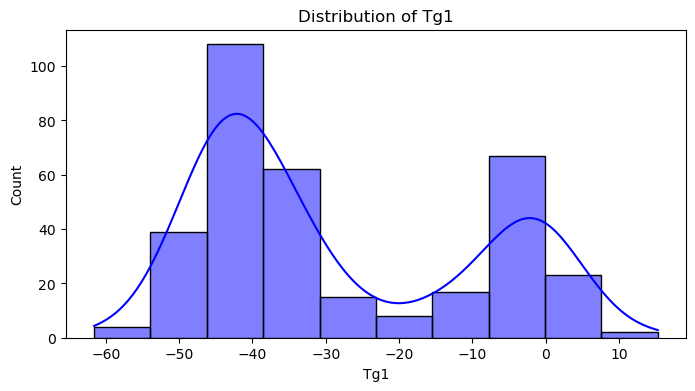

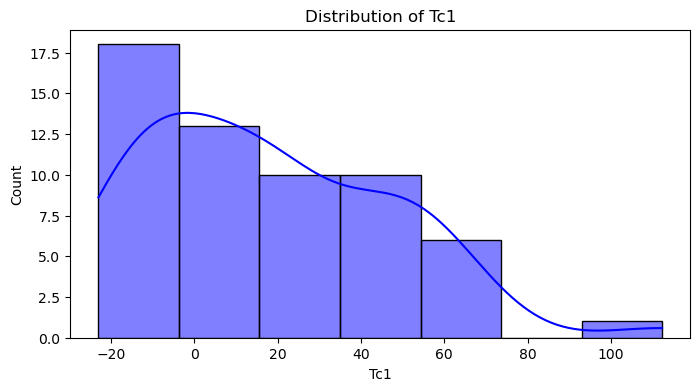

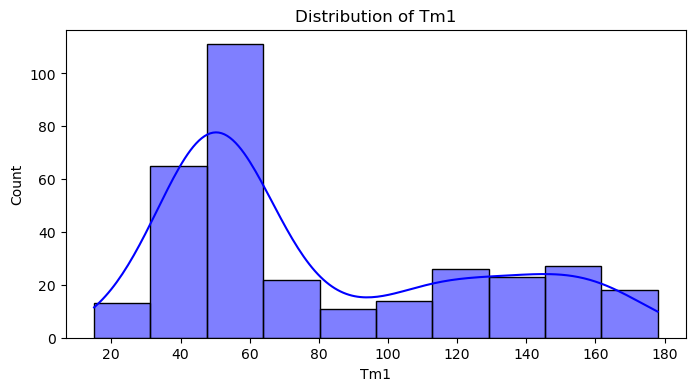

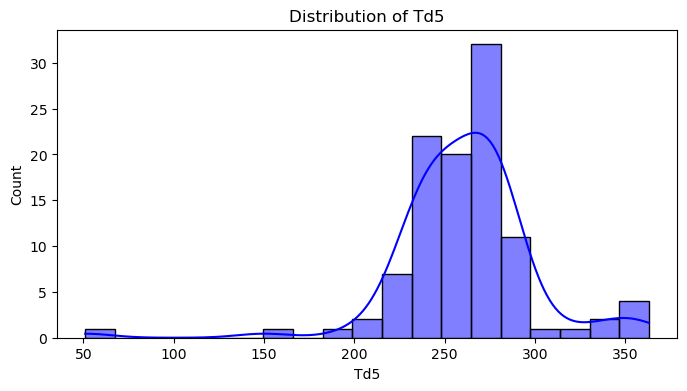

In [10]:
therm_col = ['Tg1', 'Tc1', 'Tm1', 'Td5']

for col in therm_col:
    if pd.api.types.is_numeric_dtype(df_therm[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_therm[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}')
    else:
        # Count number of unique categories for dynamic figure height
        num_categories = df_therm[col].nunique()
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))  # Wider and taller figure
        order = df_therm[col].value_counts().index  # Sort by frequency
        sns.countplot(y=col, data=df_therm, order=order, color='green')

        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()

# Merge

In [11]:
# Create merged Dataset
df_merged_fnl = pd.concat([df_physicochem, df_therm.drop(columns=['Study_id', 'Instance'])], axis=1)

In [12]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

## Fix typos, excl. special characters

In [13]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val

In [14]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,scl_pha_ratio_mol,3hb_ratio_mol,3hv_ratio_mol,mcl_pha_ratio_mol,3hhx_ratio_mol,3hhp_ratio_mol,3ho_ratio_mol,3hn_ratio_mol,...,dm1,dm2,dhc1,dhc2,enthaply_units,crystallinity_percentage,tm_mean,tm_max,tc_mean,tc_max
0,1.0,1.0,99.87,99.81,0.06,0.13,0.09,0.0,0.04,0.0,...,NaN,NaN,NaN,NaN,NaN,52.0,176.0,176.0,NaN,NaN
1,2.0,1.0,98.88,98.88,0.00,1.12,0.92,0.0,0.20,0.0,...,47.00,NaN,NaN,NaN,J/g,NaN,161.0,167.0,59.0,59.0
2,2.0,2.0,98.74,98.74,0.00,1.26,0.98,0.0,0.28,0.0,...,41.00,NaN,NaN,NaN,J/g,NaN,149.0,157.0,58.0,58.0
3,3.0,1.0,94.60,94.60,0.00,5.40,0.00,0.0,0.00,0.0,...,34.50,NaN,NaN,NaN,J/g,NaN,161.0,161.0,NaN,NaN
4,4.0,1.0,0.00,0.00,0.00,100.00,6.10,0.0,92.60,0.0,...,23.43,NaN,NaN,NaN,J/g,16.0,52.0,52.0,NaN,NaN


In [15]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [16]:
df_clean.columns

Index(['study_id', 'instance', 'scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhx_ratio_mol',
       '3hhp_ratio_mol', '3ho_ratio_mol', '3hn_ratio_mol', '3hd_ratio_mol',
       '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'mw', 'mn', 'density', 'density_units',
       'pdi', 'additive_1', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive_2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'unnamed_31', 'row_no', 'tg1',
       'tg2', 'tc1', 'tc2', 'tmc', 'tm1', 'tm2', 'td5', 'tdeg',
       'temperature_units', 'dm1', 'dm2', 'dhc1', 'dhc2', 'enthaply_units',
       'crystallinity_percentage', 'tm_mean', 'tm_max', 'tc_mean', 'tc_max'],
      dtype='object')

In [17]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

## Drop features with more than 30% missing values

In [18]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.70]
df_clean.columns

Index(['study_id', 'instance', 'scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhx_ratio_mol',
       '3hhp_ratio_mol', '3ho_ratio_mol', '3hn_ratio_mol', '3hd_ratio_mol',
       '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'mw', 'mn', 'pdi', 'additive_1',
       'additive1_type', 'additive1_percentage_wt', 'additive_2',
       'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'row_no', 'tg1', 'tm1',
       'temperature_units', 'dm1', 'enthaply_units',
       'crystallinity_percentage', 'tm_mean', 'tm_max'],
      dtype='object')

## Feature engineering

In [19]:
df_clean['additive1_type'].value_counts()

additive1_type
no_additive                                 378
reinforcment_and_stiffening_modifiers        33
biofunctional_and_enviromental_additives     15
nucleating_agent                              3
plasticizers_and_flexibility_enhancers        3
Name: count, dtype: int64

In [20]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive                              426
reinforcment_and_stiffening_modifiers      6
Name: count, dtype: int64

## Feature selection

In [21]:
# Select Features and Target
features = ['scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhx_ratio_mol',
       '3hhp_ratio_mol', '3ho_ratio_mol', '3hn_ratio_mol', '3hd_ratio_mol',
       '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'mw', 'mn', 'pdi',  'additive1_type', 'additive1_percentage_wt', 
       'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt',  'tg1', 'tm1',
       'crystallinity_percentage', 'tm_mean', 'tm_max'
           ]

In [22]:
df_new = df_clean[features]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   scl_pha_ratio_mol                    431 non-null    float64
 1   3hb_ratio_mol                        431 non-null    float64
 2   3hv_ratio_mol                        431 non-null    float64
 3   mcl_pha_ratio_mol                    431 non-null    float64
 4   3hhx_ratio_mol                       426 non-null    float64
 5   3hhp_ratio_mol                       431 non-null    float64
 6   3ho_ratio_mol                        431 non-null    float64
 7   3hn_ratio_mol                        431 non-null    float64
 8   3hd_ratio_mol                        426 non-null    float64
 9   3hud_ratio_mol                       431 non-null    float64
 10  3hdd_ratio_mol                       430 non-null    float64
 11  3htrid_ratio_mol                

## Save

In [23]:
# Download United Dataset
df_new.to_csv('mclPHA_data_new.csv', index=False)